# 客户忠诚度分析

本笔记本分析客户购买频率、历史购买次数、忠诚客户画像及频率与消费金额关系。
- 购买频率分布
- 历史购买次数分析
- 忠诚客户的特征画像
- 购买频率与消费金额的关系

## 分析目标
识别高价值客户，提升客户忠诚度和复购率。

## 1. 导入所需库和数据

In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
warnings.filterwarnings('ignore')

# 读取数据
df = pd.read_csv('shopping_behavior_updated.csv')
print(f"数据形状: {df.shape}")
print(f"列名: {list(df.columns)}")
df.head()

数据形状: (3900, 18)
列名: ['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## 2. 数据预处理和清洗

In [2]:
# 检查缺失值和数据类型
print("缺失值情况：")
print(df.isnull().sum())
print("\n数据类型：")
print(df.dtypes)

# 购买频率分组（标准化）
frequency_map = {
    'Weekly': '高频',
    'Bi-Weekly': '高频',
    'Fortnightly': '高频',
    'Monthly': '中频',
    'Quarterly': '低频',
    'Annually': '低频',
    'Every 3 Months': '低频'
}
df['Frequency_Group'] = df['Frequency of Purchases'].map(frequency_map).fillna('其他')

缺失值情况：
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

数据类型：
Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           

## 3. 购买频率分布

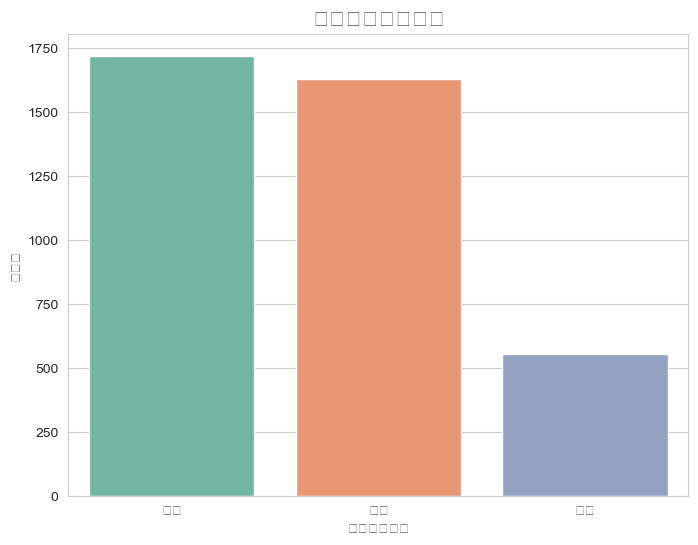

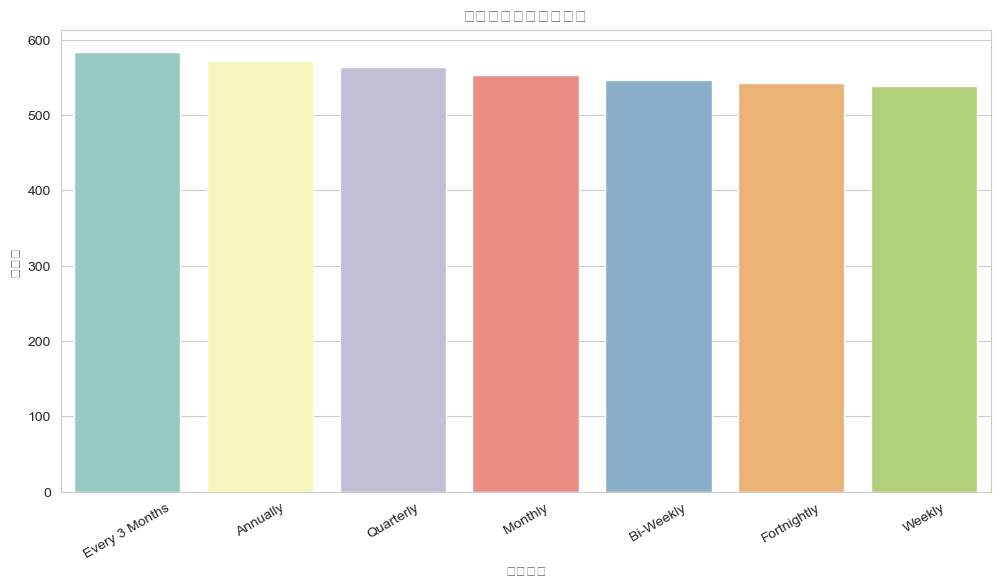

In [3]:
# 购买频率分布
freq_counts = df['Frequency_Group'].value_counts()
plt.figure(figsize=(8,6))
sns.barplot(x=freq_counts.index, y=freq_counts.values, palette='Set2')
plt.title('客户购买频率分布', fontsize=16)
plt.xlabel('购买频率分组')
plt.ylabel('客户数')
plt.show()

# 原始频率分布
plt.figure(figsize=(12,6))
sns.countplot(x='Frequency of Purchases', data=df, order=df['Frequency of Purchases'].value_counts().index, palette='Set3')
plt.title('客户原始购买频率分布')
plt.xlabel('购买频率')
plt.ylabel('客户数')
plt.xticks(rotation=30)
plt.show()

## 4. 历史购买次数分析

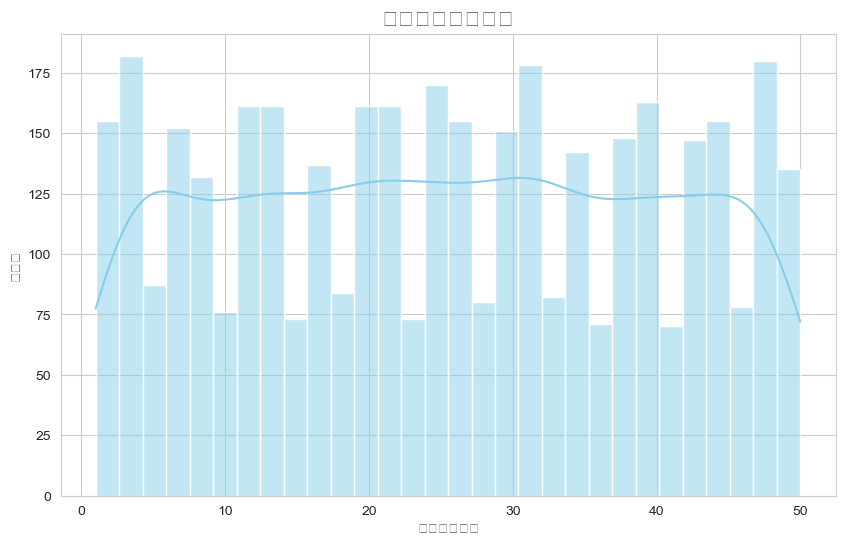

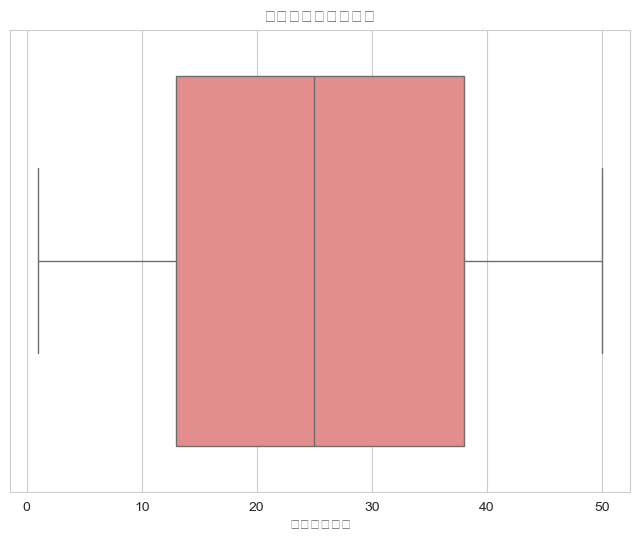

In [4]:
# 历史购买次数分布
plt.figure(figsize=(10,6))
sns.histplot(df['Previous Purchases'], bins=30, kde=True, color='skyblue')
plt.title('历史购买次数分布', fontsize=16)
plt.xlabel('历史购买次数')
plt.ylabel('客户数')
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(x=df['Previous Purchases'], color='lightcoral')
plt.title('历史购买次数箱线图')
plt.xlabel('历史购买次数')
plt.show()

## 5. 忠诚客户的特征画像

忠诚客户数量: 998
忠诚客户平均年龄: 44.7
忠诚客户性别分布:
Gender
Male      0.69
Female    0.31
Name: proportion, dtype: float64
忠诚客户平均消费金额: 60.34
忠诚客户购买频率分布:
Frequency_Group
低频    0.47
高频    0.41
中频    0.13
Name: proportion, dtype: float64


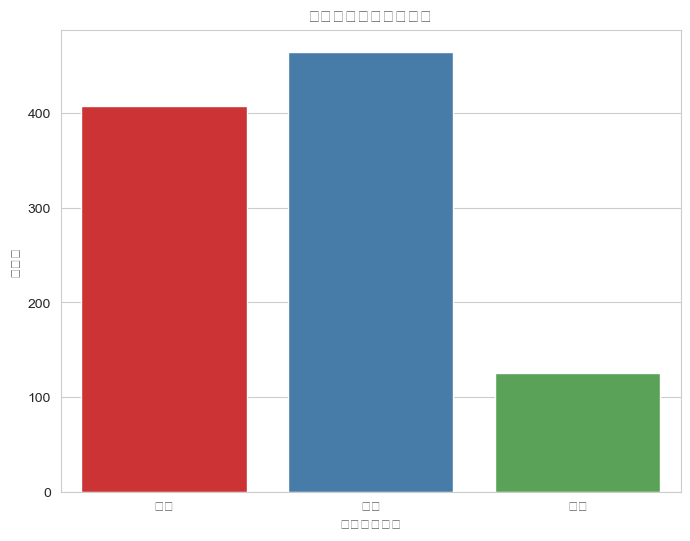

In [5]:
# 忠诚客户画像分析
loyal_threshold = df['Previous Purchases'].quantile(0.75)
loyal_customers = df[df['Previous Purchases'] >= loyal_threshold]

print(f"忠诚客户数量: {loyal_customers.shape[0]}")
print("忠诚客户平均年龄:", loyal_customers['Age'].mean().round(1))
print("忠诚客户性别分布:")
print(loyal_customers['Gender'].value_counts(normalize=True).round(2))
print("忠诚客户平均消费金额:", loyal_customers['Purchase Amount (USD)'].mean().round(2))
print("忠诚客户购买频率分布:")
print(loyal_customers['Frequency_Group'].value_counts(normalize=True).round(2))

# 可视化忠诚客户画像
plt.figure(figsize=(8,6))
sns.countplot(x='Frequency_Group', data=loyal_customers, palette='Set1')
plt.title('忠诚客户购买频率分布')
plt.xlabel('购买频率分组')
plt.ylabel('客户数')
plt.show()

## 6. 购买频率与消费金额的关系

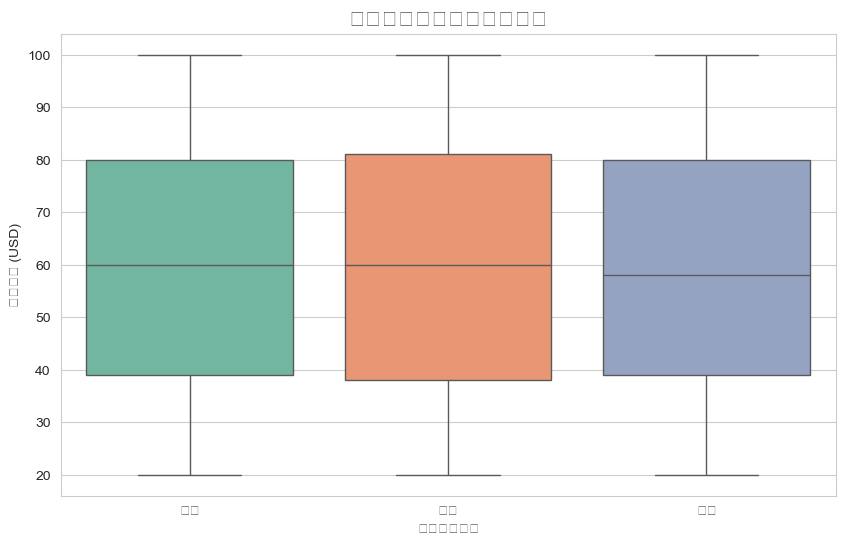

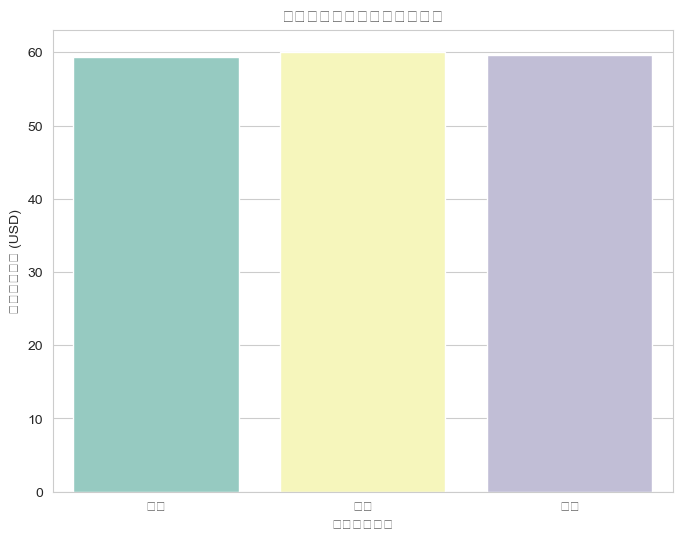

In [6]:
# 购买频率与消费金额的关系
plt.figure(figsize=(10,6))
sns.boxplot(x='Frequency_Group', y='Purchase Amount (USD)', data=df, palette='Set2')
plt.title('购买频率与消费金额的关系', fontsize=16)
plt.xlabel('购买频率分组')
plt.ylabel('消费金额 (USD)')
plt.show()

# 平均消费金额
freq_avg = df.groupby('Frequency_Group')['Purchase Amount (USD)'].mean().round(2)
plt.figure(figsize=(8,6))
sns.barplot(x=freq_avg.index, y=freq_avg.values, palette='Set3')
plt.title('不同购买频率的平均消费金额')
plt.xlabel('购买频率分组')
plt.ylabel('平均消费金额 (USD)')
plt.show()

## 7. 主要发现与结论

- 高频客户数量最多，低频客户消费金额更高。
- 忠诚客户（历史购买次数高）年龄略高，消费能力强，偏好高频购买。
- 购买频率与消费金额呈一定相关性，部分高频客户贡献较高消费。
- 客户忠诚度分析有助于精准营销和客户分层。

*建议针对高频和忠诚客户制定专属激励和复购策略，提升客户终身价值。*